In [32]:
words = open("names.txt", 'r').read().splitlines()

In [33]:
#Creating a dictionary to store the occurance of 2 char together
b = {}
for w in words:
  chs = ['<S>'] + list(w) + ['<E>'] #special starting and ending char for every word
  for ch1, ch2 in zip(chs, chs[1:]): #zip allows to have 1-1 char together at a time
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1 #defalt = 0, +1 when occurs

In [34]:
type(b)

dict

In [35]:
frequency = sorted(b.items(), key = lambda kv: -kv[1])

In [36]:
#using pytorch and arrays to map frequency
import torch

In [37]:
a = torch.zeros((5, 5), dtype=torch.int32)

In [38]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [49]:
N = torch.zeros((28, 28), dtype=torch.int32)

In [50]:
chars = sorted(list(set(''.join(words)))) 
# join:joins every words to form a single long word
# set:doesn't allow there to be any duplicates in the word


In [51]:
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

In [52]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [53]:
for w in words:
  chs = ['<S>'] + list(w) + ['<E>'] 
  for ch1, ch2 in zip(chs, chs[1:]):
      ix1 = stoi[ch1]
      ix2 = stoi[ch2]
      N[ix1,ix2] += 1

In [55]:
itos = {i:s for s,i in stoi.items()}

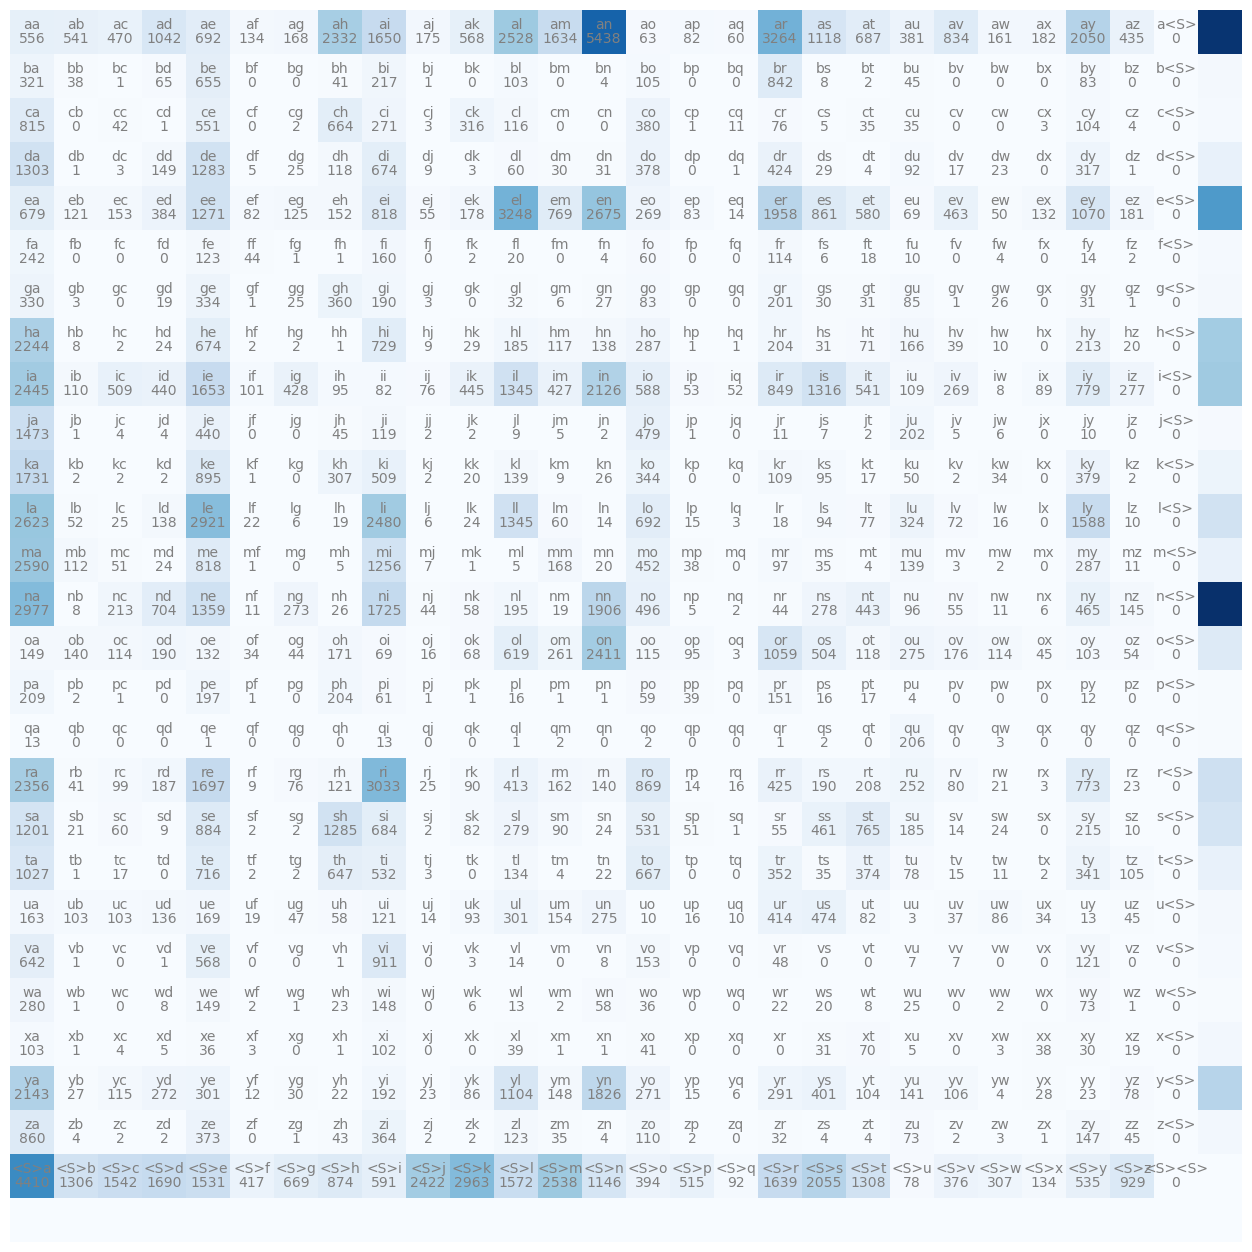

In [56]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');